In [1]:
import csv
import os 
import pandas as pd
import statistics 
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
folder_path = "/Users/khushi/Desktop/DS2500 Project/files"

In [3]:
# Dictionary to store dataframes with appropriate labels
dataframes = {}

# Loop through each file in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith('.csv'):
        # Create a label by removing file suffix & extract the relevant part before "_prices_"
        label = file_name.split('_prices_')[0]  
        
        #Specific condition for CPI file 
        if file_name == "cpi_growth_rate_2010_to_2024.csv":
            label = "cpi_growth"
            
        # Read the CSV file into a DataFrame
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path)
        
        # Add DataFrame to the dictionary with the label
        dataframes[label] = df
        
        # Print the label
        print(label)

fed_funds_rate_monthly_data_2010_to_2024.csv
copper
brent_crude
cpi_growth
usd_jpy
unemployment_rate_monthly_data_2010_to_2024.csv
sp500
platinum
gold
silver
vix
industrial_production_monthly_data_2010_to_2024.csv


In [4]:
# This analysis requires comparing commodity price returns 

# Function to calculate percentage change
def calculate_returns(prices):
    returns = []
    for i in range(1, len(prices)):
        prev = prices[i - 1]
        curr = prices[i]
        
        # Calculate percentage change: (current - previous) / previous * 100
        returns.append(((curr - prev) / prev) * 100)
    return [None] + returns

In [5]:
commodities = ['copper', 'gold', 'silver', 'platinum']

for commodity, df in dataframes.items():
    if commodity in commodities:  
        # Skip the first three rows and reset the index
        df = df.iloc[3:].reset_index(drop=True)
        
        # Convert the 'Adj Close' column to numeric
        df['Adj Close'] = pd.to_numeric(df['Adj Close'], errors='coerce')
        
        # Calculate returns and add to the DataFrame
        df['Returns'] = calculate_returns(df['Adj Close'])

        # Update the dataframe in the dictionary
        dataframes[commodity] = df

In [6]:
copper_prices = dataframes.get('copper', None)
print(copper_prices.head(10))

        Price  Adj Close        Close         High          Low         Open  \
0  2010/11/26     3.7510  3.750999928  3.751499891  3.703500032  3.703500032   
1  2010/11/29     3.7580  3.757999897  3.798000097  3.700999975  3.750999928   
2  2010/11/30     3.8230  3.822999954  3.832999945  3.713000059   3.75999999   
3  2010/12/01     3.9460  3.946000099  3.953000069  3.788500071  3.790999889   
4  2010/12/02     3.9770  3.976999998   3.99000001  3.936000109  3.951999903   
5  2010/12/03     3.9950  3.994999886  4.010000229  3.950000048  3.960500002   
6  2010/12/06     4.0040  4.004000187  4.019000053  3.976999998  4.010000229   
7  2010/12/07     4.0440  4.044000149        4.125  3.980000019  4.006000042   
8  2010/12/08     4.0945  4.094500065  4.109000206   3.98149991  4.019000053   
9  2010/12/09     4.0815  4.081500053  4.139500141  4.053999901        4.125   

  Volume   Returns  
0  24760       NaN  
1  16360  0.186616  
2   5000  1.729645  
3   1301  3.217372  
4    907  0.78

In [7]:
# Edit each commodity DataFrame to retain only `Date` and `Returns`
for commodity in commodities:
    dataframes[commodity] = dataframes[commodity][['Price', 'Returns']]
    dataframes[commodity] = dataframes[commodity].rename(columns={'Price': 'Date'})
    dataframes[commodity] = dataframes[commodity].rename(columns={'Returns': f'{commodity}_returns'})
    dataframes[commodity]['Date'] = dataframes[commodity]['Date'].apply(lambda x: datetime.strptime(x, '%Y/%m/%d'))
    dataframes[commodity]['Date'] = dataframes[commodity]['Date'].apply(lambda x: x.strftime('%Y-%m-%d'))

In [8]:
# Load CPI Data and Rename Columns
cpi_df = dataframes['cpi_growth'] 
cpi_df = dataframes['cpi_growth'].rename(columns={'DATE': 'Date'})

In [9]:
# Ensure 'Date' column in data is in datetime format
cpi_df['Date'] = pd.to_datetime(cpi_df['Date'])

# Use CPI DataFrame as the base to merge commodity data 
cpi_vs_commodity_data = cpi_df.copy()

for commodity in commodities:
    
    dataframes[commodity]['Date'] = pd.to_datetime(dataframes[commodity]['Date'])
    
    # Extract the month and year to group by
    dataframes[commodity]['Month'] = dataframes[commodity]['Date'].dt.to_period('M')
    
    # Get the first or closest date in each month
    first_day_commodity = (
        dataframes[commodity]
        .loc[dataframes[commodity].groupby('Month')['Date'].idxmin()]
        .copy()
    )
    
    # Drop rows where returns are NaN
    first_day_commodity = first_day_commodity.dropna(subset=[f'{commodity}_returns'])
    
    # Set the 'Date' column to the first day of each month
    first_day_commodity['Date'] = first_day_commodity['Month'].dt.start_time
    
    first_day_commodity = first_day_commodity[['Date', f'{commodity}_returns']]
    
    # Merge the first-day returns for the commodity into the final DataFrame
    cpi_vs_commodity_data = pd.merge(cpi_vs_commodity_data, first_day_commodity, on='Date', how='left')


print(cpi_vs_commodity_data)


          Date  CPI Growth  copper_returns  gold_returns  silver_returns  \
0   2010-11-01    0.042065             NaN           NaN             NaN   
1   2010-12-01    0.171844        3.217372      0.166069        0.720245   
2   2011-01-01    0.476323        0.270303      0.105552        0.601750   
3   2011-02-01    0.493137        1.999545      0.434842        1.242281   
4   2011-03-01    0.975107        0.279138      1.518477        1.810435   
..         ...         ...             ...           ...             ...   
156 2023-11-01   -0.201514        0.096114     -0.322381       -0.682983   
157 2023-12-01   -0.099332        2.089316      1.614250        0.814460   
158 2024-01-01    0.544750       -0.296357      0.096974       -0.503085   
159 2024-02-01    0.618967       -1.281229      0.224570        0.342712   
160 2024-03-01    0.646417        0.534618      2.013978        2.135354   

     platinum_returns  
0                 NaN  
1            1.066407  
2            0.

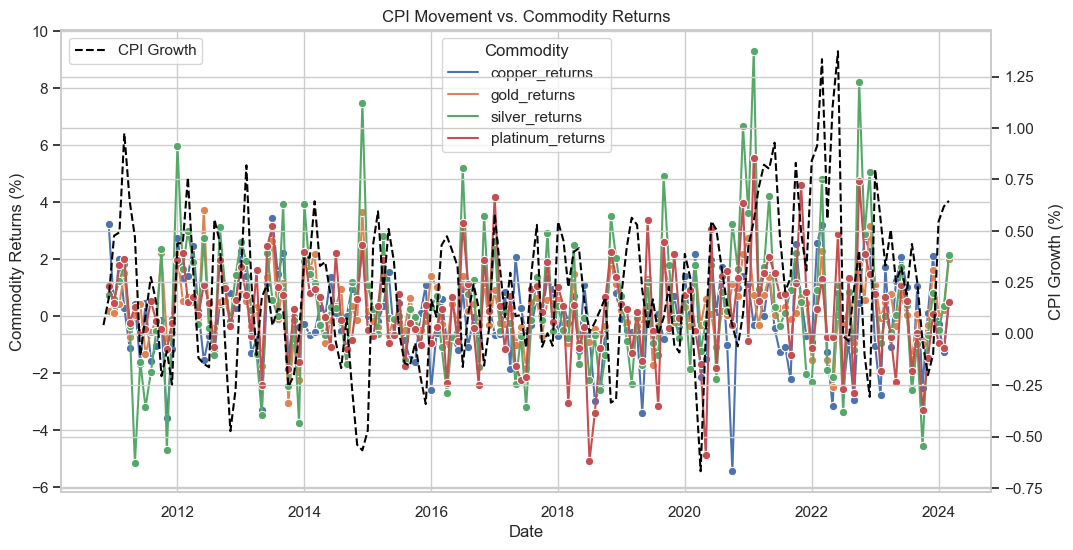

In [10]:
# Set plot style
sns.set(style="whitegrid")

# Melt the DataFrame for easier plotting
melted_data = cpi_vs_commodity_data.melt(
    id_vars=['Date', 'CPI Growth'], 
    value_vars=['copper_returns', 'gold_returns', 'silver_returns', 'platinum_returns'],
    var_name='Commodity', 
    value_name='Returns'
)

# Plot CPI growth and commodity returns on separate y-axes
plt.figure(figsize=(12, 6))
sns.lineplot(data=melted_data, x='Date', y='Returns', hue='Commodity', marker='o')
plt.ylabel("Commodity Returns (%)")
plt.twinx()
sns.lineplot(data=cpi_vs_commodity_data, x='Date', y='CPI Growth', color='black', linestyle='--', label='CPI Growth')
plt.ylabel("CPI Growth (%)")
plt.legend(loc='upper left')
plt.title("CPI Movement vs. Commodity Returns")
plt.show()

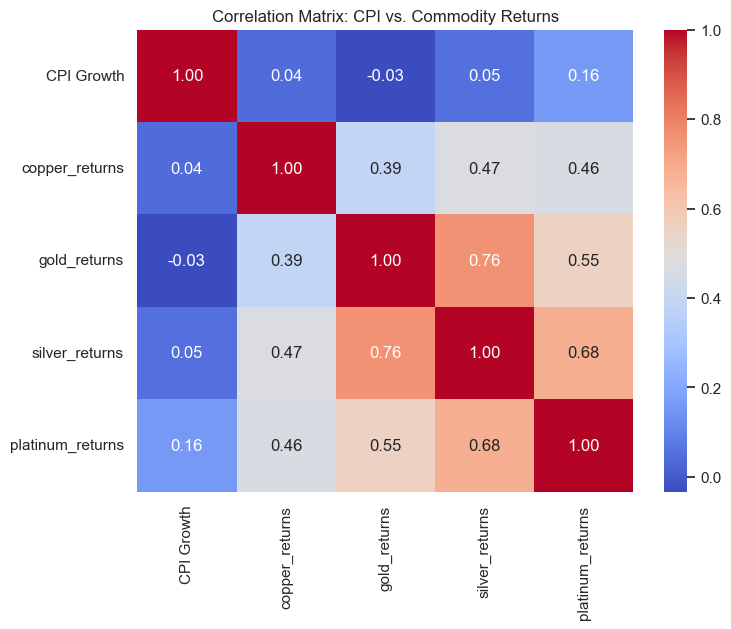

In [11]:
# Compute correlation matrix
correlation_matrix = cpi_vs_commodity_data[['CPI Growth', 'copper_returns', 'gold_returns', 'silver_returns', 'platinum_returns']].corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix: CPI vs. Commodity Returns")
plt.show()

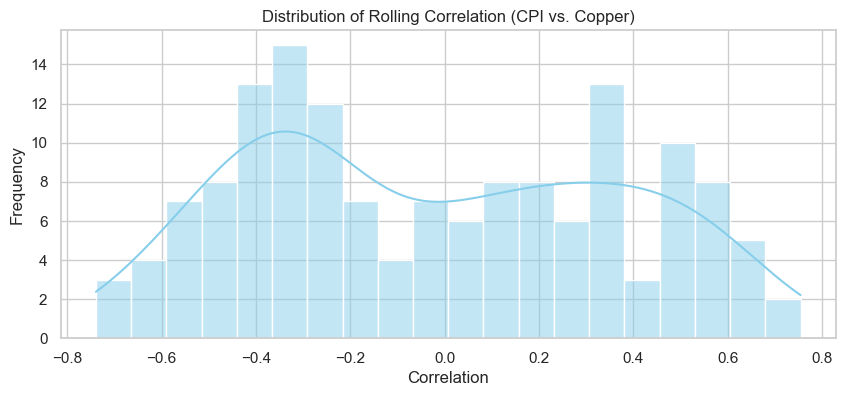

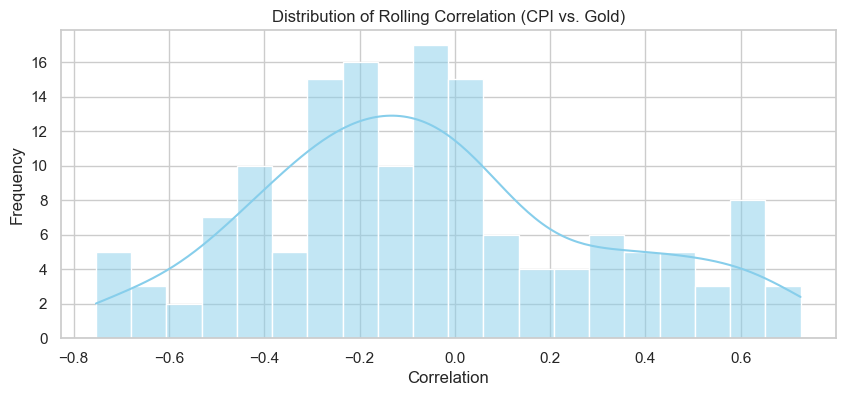

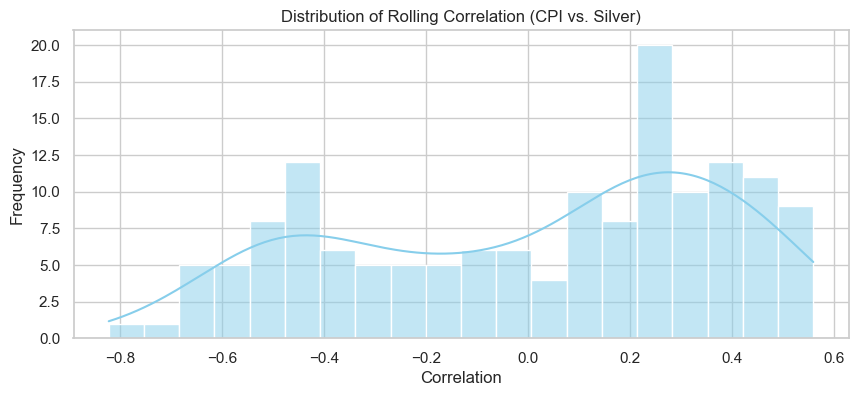

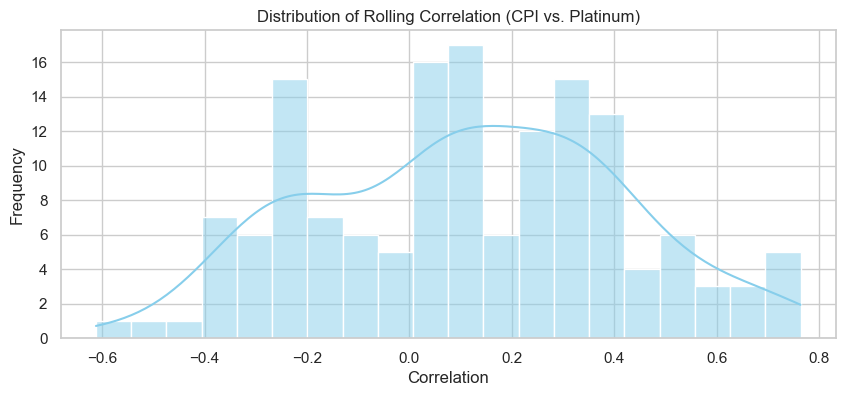

In [12]:
# Rolling correlation (window size = 12 months)
rolling_correlations = {}
window_size = 12

for commodity in commodities:
    rolling_correlations[commodity] = (
        cpi_vs_commodity_data['CPI Growth']
        .rolling(window=window_size)
        .corr(cpi_vs_commodity_data[f'{commodity}_returns'])
    )

# Plot rolling correlation distribution
for commodity in commodities:
    plt.figure(figsize=(10, 4))
    sns.histplot(rolling_correlations[commodity].dropna(), kde=True, bins=20, color='skyblue')
    plt.title(f"Distribution of Rolling Correlation (CPI vs. {commodity.capitalize()})")
    plt.xlabel("Correlation")
    plt.ylabel("Frequency")
    plt.show()